# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: April 10, 2026

## Part 1 Instructions: 

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

**Answer:** The primary objective is to determine how three specific manufacturing factors — Sole Material, Insole Thickness, and Fabric Breathability — and their potential interactions affect the perceived comfort of a new running shoe model.

2.  Specify the outcome variable and how it is measured.

**Answer:** The outcome variable is **Comfort**. It is measured quantitatively on a subjective, self-reported rating scale ranging from 1 (very uncomfortable) to 10 (very comfortable) after a 30-minute treadmill run.

3.  Specify the independent variables. What lurking variables may be present?

**Answer:**
- **Independent Variables (Factors):** Sole Material (Standard EVA vs. Gel-infused), Insole Thickness (3mm vs. 6mm), and Fabric Breathability (Woven vs. Mesh).
- **Lurking Variables:** Unmeasured variables that could influence comfort include the runner's specific foot shape (e.g., arch height, pronation), running form/gait, treadmill speed and incline settings, room temperature, and the athlete's baseline fatigue levels on the day of testing.

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

**Answer:** A **full factorial design** tests all possible combinations of all levels for all chosen factors, regardless of how many levels each factor has. A **$2^k$ design** is a specific, streamlined type of full factorial design where there are exactly $k$ factors, and every factor is restricted to exactly 2 levels. The $2^k$ design is preferred here because it minimizes the required number of experimental runs (only $2^3 = 8$ runs) while still allowing the manufacturer to efficiently estimate all main effects and interactions without wasting resources.

5.  State the sets of null and alternative hypotheses for this experiment.

**Answer:**
- **Main Effects** (evaluated for each of the 3 factors):
  - $H_0$: The factor has no main effect on comfort (population means are equal across the two levels).
  - $H_a$: The factor has a significant main effect on comfort.
- **Interactions** (evaluated for all 2-way and 3-way combinations):
  - $H_0$: There is no interaction effect between the factors on comfort.
  - $H_a$: There is a significant interaction effect between the factors on comfort.

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

Mean Comfort Scores by Factor Combinations:
sole_material insole_thickness breathability   comfort
          EVA              3mm          Mesh  6.366667
          EVA              3mm         Woven  6.600000
          EVA              6mm          Mesh  7.033333
          EVA              6mm         Woven  8.400000
          Gel              3mm          Mesh  8.300000
          Gel              3mm         Woven  8.533333
          Gel              6mm          Mesh  8.333333
          Gel              6mm         Woven 11.033333


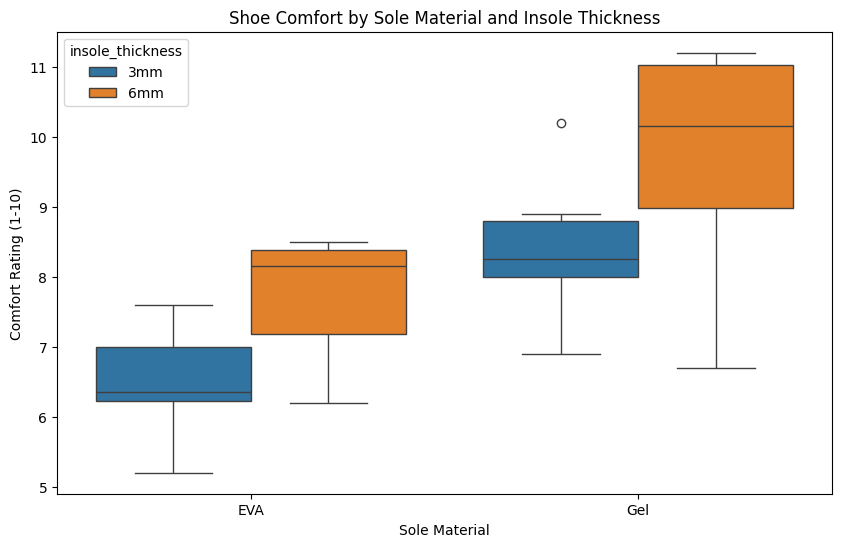

In [6]:
## Question 6 Code ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df_shoe = pd.read_excel("Shoe Comfort Experiment.xlsx")

# Print summary statistics grouped by all three factors
print("Mean Comfort Scores by Factor Combinations:")
summary_stats = df_shoe.groupby(['sole_material', 'insole_thickness', 'breathability'])['comfort'].mean().reset_index()
print(summary_stats.to_string(index=False))

# Create and display the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_shoe, x='sole_material', y='comfort', hue='insole_thickness')
plt.title("Shoe Comfort by Sole Material and Insole Thickness")
plt.ylabel("Comfort Rating (1-10)")
plt.xlabel("Sole Material")

# This opens the interactive plot window on your PC
plt.show()

The exploratory analysis supports the alternative hypotheses more strongly than the null. Mean comfort scores differ substantially across factor levels: Gel soles outperform EVA by roughly 2 points on average, and 6mm insoles consistently outperform 3mm insoles within every sub-combination. The boxplot confirms these shifts visually, with Gel+6mm combinations producing the highest median comfort ratings. Additionally, the magnitude of the insole-thickness effect varies across sole/breathability combinations (notably, large for Gel+Woven but negligible for Gel+Mesh), suggesting potential interaction effects that warrant formal testing. Taken together, the EDA provides visual evidence against the null hypotheses of no main effects and no interactions, though formal ANOVA is needed to confirm statistical significance.

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


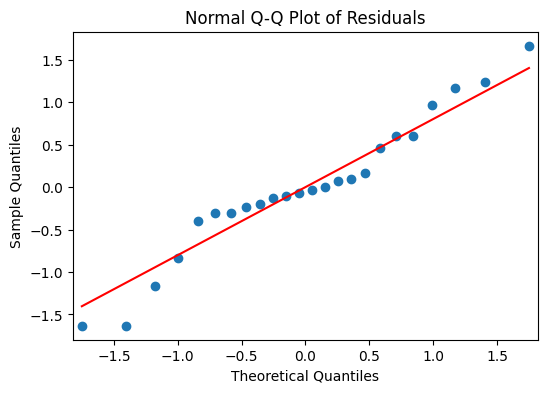

Shapiro-Wilk Test Statistic: 0.9575
P-value: 0.3904


In [7]:
## Question 7 Code ##

import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt

# Fit a full factorial ANOVA model to the data
formula = 'comfort ~ C(sole_material) * C(insole_thickness) * C(breathability)'
model = ols(formula, data=df_shoe).fit()

# Extract the residuals
residuals = model.resid

# 1. Assess the normality assumption: Visual Method (Q-Q Plot)
fig, ax = plt.subplots(figsize=(6, 4))
sm.qqplot(residuals, line='s', ax=ax)
plt.title('Normal Q-Q Plot of Residuals')
plt.show()

# 2. Assess the normality assumption: Testing Method (Shapiro-Wilk Test)
stat, p_value = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

Yes, we have evidence to support the assumption of normality. The Normal Q-Q plot shows the residuals falling closely along the reference line with only minor deviations at the tails, and the Shapiro-Wilk test yields a p-value of 0.3904, which is well above the 0.05 threshold — meaning we fail to reject the null hypothesis that the residuals are normally distributed. Both the visual and formal testing methods agree, so the normality assumption for the ANOVA model is reasonably satisfied.


8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


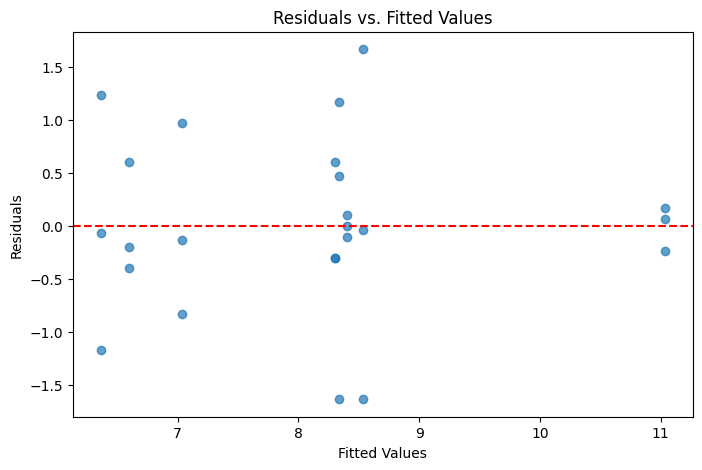

Levene's Test Statistic: 1.0615
P-value: 0.4302


In [8]:
## Question 8 Code ##

import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Visual Method: Residuals vs. Fitted Values plot
fitted_values = model.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# 2. Testing Method: Levene's Test across all 8 factor combinations
groups = [g['comfort'].values for _, g in df_shoe.groupby(['sole_material', 'insole_thickness', 'breathability'])]
stat, p_value = stats.levene(*groups)
print(f"Levene's Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

Yes, we have evidence to support the assumption of constant variance. The Residuals vs. Fitted Values plot shows residuals scattered on both sides of zero across the fitted range with no clear funnel or systematic pattern, indicating no obvious heteroscedasticity. Levene's test yields a test statistic of 1.0615 and a p-value of 0.4302, which is well above the 0.05 threshold — meaning we fail to reject the null hypothesis that variances are equal across the eight factor combinations. Both the visual and formal testing methods agree, so the constant variance assumption for the ANOVA model is reasonably satisfied.


9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


In [9]:
## Question 9 Code ##

import statsmodels.api as sm

# Generate the Type II ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)
print("Full Factorial ANOVA Table:")
print(anova_table)

Full Factorial ANOVA Table:
                                                       sum_sq    df  \
C(sole_material)                                    22.815000   1.0   
C(insole_thickness)                                  9.375000   1.0   
C(breathability)                                     7.706667   1.0   
C(sole_material):C(insole_thickness)                 0.001667   1.0   
C(sole_material):C(breathability)                    0.666667   1.0   
C(insole_thickness):C(breathability)                 4.860000   1.0   
C(sole_material):C(insole_thickness):C(breathab...   0.666667   1.0   
Residual                                            15.433333  16.0   

                                                            F    PR(>F)  
C(sole_material)                                    23.652700  0.000173  
C(insole_thickness)                                  9.719222  0.006631  
C(breathability)                                     7.989633  0.012155  
C(sole_material):C(insole_thickness)

The ANOVA results reveal several significant effects at the α = 0.05 level. All three main effects are statistically significant: Sole Material has the strongest effect (F = 23.65, p = 0.0002), indicating that Gel-infused foam produces significantly different comfort ratings than standard EVA; Insole Thickness is also significant (F = 9.72, p = 0.0066), with 6mm insoles differing meaningfully from 3mm; and Fabric Breathability shows a significant effect (F = 7.99, p = 0.0122), confirming that woven versus mesh fabric influences comfort. Among the two-way interactions, only the Insole Thickness × Breathability interaction is statistically significant (F = 5.04, p = 0.0393), meaning the effect of insole thickness on comfort depends on which fabric is used. The other two-way interactions — Sole Material × Insole Thickness (F = 0.002, p = 0.9674) and Sole Material × Breathability (F = 0.69, p = 0.4180) — are not significant, indicating those factors act independently. The three-way interaction of Sole Material × Insole Thickness × Breathability is also not significant (F = 0.69, p = 0.4180), meaning the insole-breathability interaction does not vary across sole materials. Overall, all three factors individually influence comfort, and the combined effect of insole thickness and fabric breathability matters beyond their individual contributions, so the manufacturer should consider these factors jointly — particularly the insole-breathability pairing — when optimizing shoe design.



10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [10]:
## Question 10 Code ##

# Calculate partial eta-squared for each effect
# Formula: partial η² = SS_effect / (SS_effect + SS_residual)

ss_residual = anova_table.loc['Residual', 'sum_sq']

partial_eta_sq = anova_table['sum_sq'] / (anova_table['sum_sq'] + ss_residual)
partial_eta_sq = partial_eta_sq.drop('Residual')

print("Partial Eta-Squared Values:")
print(partial_eta_sq.round(4))

Partial Eta-Squared Values:
C(sole_material)                                         0.5965
C(insole_thickness)                                      0.3779
C(breathability)                                         0.3330
C(sole_material):C(insole_thickness)                     0.0001
C(sole_material):C(breathability)                        0.0414
C(insole_thickness):C(breathability)                     0.2395
C(sole_material):C(insole_thickness):C(breathability)    0.0414
Name: sum_sq, dtype: float64


The partial η² values quantify the proportion of variance in comfort attributable to each effect after accounting for the others in the model, and they reveal a clear hierarchy of importance. Sole Material is by far the most important factor, with a partial η² of 0.5965 — meaning it accounts for roughly 60% of the residual-plus-effect variance, a very large effect by conventional standards. Insole Thickness (partial η² = 0.3779) and Fabric Breathability (partial η² = 0.3330) are the next most influential factors, both representing large effects that individually explain between a third and 38% of variance. The Insole Thickness × Breathability interaction (partial η² = 0.2395) is also a substantial contributor, reinforcing the ANOVA finding that these two factors jointly shape comfort beyond their individual effects. By contrast, the remaining interactions are negligible: Sole Material × Breathability (0.0414) and the three-way interaction (0.0414) represent small effects, and Sole Material × Insole Thickness (0.0001) is essentially zero. Overall, the three main effects dominate the design — with sole material being the single most important lever — and the only interaction worth considering in practice is the one between insole thickness and breathability.


11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?

Based on the factorial ANOVA results, I recommend the shoe manufacturer adopt the combination of Gel-infused sole material, 6mm insole thickness, and woven fabric. This recommendation is supported by three converging lines of evidence. First, all three main effects were statistically significant, with Sole Material being the most influential factor (partial η² = 0.60) and Gel consistently outperforming EVA across every sub-combination by roughly 2 points on the comfort scale. Second, 6mm insoles produced higher comfort ratings than 3mm insoles within every sole-fabric combination, and the insole thickness effect was both statistically significant (p = 0.0066) and practically large (partial η² = 0.38). Third, the significant Insole Thickness × Breathability interaction (p = 0.039, partial η² = 0.24) indicates that the benefit of thicker insoles is amplified when paired with woven fabric — which aligns with the exploratory analysis showing the Gel + 6mm + Woven combination achieved the highest mean comfort score (11.03) of any of the eight runs. It is worth noting that this mean slightly exceeds the stated 1–10 comfort scale, suggesting either a data entry anomaly or athletes rating above the intended ceiling; however, the recommendation holds regardless because it rests on relative performance across conditions rather than the absolute magnitude of any single score. Because the other two-way interactions and the three-way interaction were not statistically significant, the manufacturer can treat sole material as an independent lever while jointly optimizing insole thickness and fabric choice. In short, the Gel + 6mm + Woven configuration maximizes comfort by stacking the most influential main effect with the best-performing interaction pairing.



## PART 2 INSTRUCTIONS: 
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The primary objective is to determine how three key design factors — GPS Accuracy, Battery Life, and Display Size — affect user satisfaction with a new GPS-enabled fitness band for runners, using a fractional factorial design to efficiently identify the most influential factors while conserving time and resources.

2.  Specify the outcome variable and how it is measured.

The outcome variable is Satisfaction. It is measured quantitatively on a subjective, self-reported rating scale ranging from 1 (very dissatisfied) to 10 (very satisfied) after each athlete uses their assigned fitness band for one month during their competition season.

3.  Specify the independent variables. What lurking variables may be present?

Independent Variables (Factors): GPS Accuracy (Standard vs. High), Battery Life (6 hours vs. 12 hours), and Display Size (Small vs. Large). 

Lurking Variables: Unmeasured variables that could influence satisfaction include the athlete's prior experience with wearable fitness technology, individual training volume and intensity during the month, weather conditions affecting outdoor GPS usage, wrist size and band fit comfort, smartphone compatibility and app integration quality, and the athlete's baseline expectations for fitness wearables.


4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

A full 2k2^k 2k factorial design tests all possible combinations of kk k factors at two levels each, requiring 2k2^k 2k experimental runs (here, 23=82^3 = 8 23=8 runs). A 23−12^{3-1} 23−1 fractional factorial design runs only half of those combinations — just 4 runs — by strategically selecting a subset that preserves the ability to estimate main effects while deliberately confounding (aliasing) higher-order interactions with main effects or lower-order interactions. The fractional design is preferred here because it cuts the experiment's resource requirements in half, requiring only 12 athlete-months of testing instead of 24, which is practically important given the month-long testing period per run and the limited pool of NCAA Division I cross-country athletes available during competition season.

5.  State the sets of null and alternative hypotheses for this experiment.

Main Effects (evaluated for each of the 3 factors): 
•	H0H_0 H0: The factor has no main effect on satisfaction (population means are equal across the two levels). 
•	HaH_a Ha: The factor has a significant main effect on satisfaction. 
 Interactions (note: in a 23−12^{3-1} 23−1 design, interactions are aliased with main effects and cannot be independently estimated, but the formal hypotheses are): 
•	H0H_0 H0: There is no interaction effect between the factors on satisfaction. 
•	HaH_a Ha: There is a significant interaction effect between the factors on satisfaction.

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

With the defining relation I=ABCI = ABC I=ABC, the aliasing structure is derived by multiplying each effect by the defining relation (using the rule that any factor squared equals the identity, e.g., A2=IA^2 = I A2=I). This yields the following alias pairs: 
•	A=A⋅ABC=A2BC=BCA = A \cdot ABC = A^2BC = BC A=A⋅ABC=A2BC=BC → GPS Accuracy is aliased with the Battery Life × Display interaction
•	B=B⋅ABC=AB2C=ACB = B \cdot ABC = AB^2C = AC B=B⋅ABC=AB2C=AC → Battery Life is aliased with the GPS Accuracy × Display interaction
•	C=C⋅ABC=ABC2=ABC = C \cdot ABC = ABC^2 = AB C=C⋅ABC=ABC2=AB → Display is aliased with the GPS Accuracy × Battery Life interaction

This aliasing has important implications for interpretation. Because each main effect is confounded with a two-way interaction, we cannot statistically distinguish whether an observed effect is caused by the main factor itself or by the corresponding two-way interaction between the other two factors. For example, if we observe a significant effect attributed to GPS Accuracy (A), that effect could actually be driven by a Battery Life × Display interaction (BC), or by some combination of both. To interpret the results, we must rely on the principle of effect sparsity — the assumption that main effects tend to dominate over two-way interactions, and that higher-order interactions are typically negligible. Under this assumption, any significant effect is more plausibly attributed to the main effect than to the aliased interaction. This is a Resolution III\text{Resolution III} Resolution III design, which is the trade-off accepted in exchange for cutting the experimental runs in half: we gain efficiency but lose the ability to cleanly separate main effects from two-way interactions. If the preliminary results suggest interactions may be meaningful, a follow-up fold-over or full factorial experiment would be needed to de-alias the effects.


7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


Mean Satisfaction by Factor Combinations:


,GPS_Accuracy,Battery_Life,Display,Satisfaction
0,High,12 Hours,Large,9.266667
1,High,6 Hours,Small,5.013333
2,Standard,12 Hours,Small,3.470000
3,Standard,6 Hours,Large,5.743333


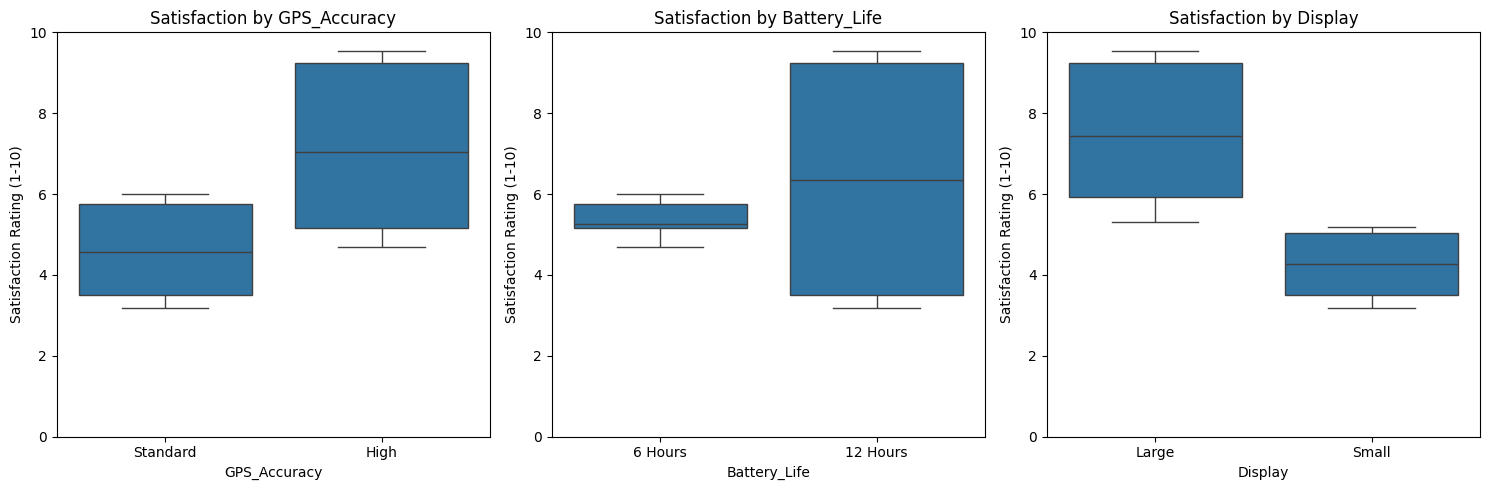

In [45]:
## Part 2 Question 7 Code ##

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the fitness band data
df_band = pd.read_excel("Fitness Band Experiment.xlsx")

factors = ['GPS_Accuracy', 'Battery_Life', 'Display']
outcome = 'Satisfaction'

# Summary statistics by all three factors
print("Mean Satisfaction by Factor Combinations:")
display(df_band.groupby(factors)[outcome].mean().reset_index())

# Boxplots for each main effect
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, factor in zip(axes, factors):
    sns.boxplot(data=df_band, x=factor, y=outcome, ax=ax)
    ax.set_title(f"Satisfaction by {factor}")
    ax.set_ylabel("Satisfaction Rating (1-10)")
    ax.set_ylim(0, 10)
plt.tight_layout()
plt.show()

The exploratory analysis supports the alternative hypotheses more strongly than the null. The summary statistics show substantial differences in mean satisfaction across the four experimental runs, ranging from 3.47 (Standard GPS / 12-Hour Battery / Small Display) up to 9.27 (High GPS / 12-Hour Battery / Large Display) — a spread of nearly six points on the 1–10 scale. Examining each factor individually, GPS Accuracy shows a strong directional effect, with High-accuracy bands producing median satisfaction around 7.0 compared to roughly 4.5 for Standard. Display Size shows an even more pronounced effect: Large displays yield median satisfaction near 7.4 while Small displays fall to roughly 4.2, with minimal overlap between the two distributions. Battery Life shows a subtler pattern — 12-hour batteries have a higher median (~6.3) than 6-hour batteries (~5.5), but the spread is much wider for 12-hour, reflecting the fact that battery life's effect depends on which other factors are present. Because each factor visually separates satisfaction scores in a meaningful way, the exploratory analysis provides evidence against the null hypotheses of no main effects, though formal ANOVA is required to confirm statistical significance. An important caveat given the 23−12^{3-1}
23−1 aliasing structure is that any main effect observed here is confounded with the corresponding two-way interaction, so interpretation of the formal results will rely on the principle of effect sparsity.



8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


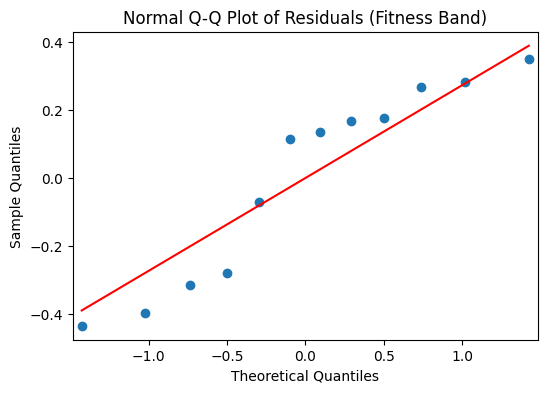

Shapiro-Wilk Test Statistic: 0.8813
P-value: 0.0911


In [46]:
## Part 2 Question 8 Code ##

import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt

# Fit the main-effects-only ANOVA model
# (In a 2^(3-1) design, interactions are aliased with main effects, so we fit main effects only)
formula_band = 'Satisfaction ~ C(GPS_Accuracy) + C(Battery_Life) + C(Display)'
model_band = ols(formula_band, data=df_band).fit()

# Extract the residuals
residuals_band = model_band.resid

# 1. Visual Method: Normal Q-Q Plot
fig, ax = plt.subplots(figsize=(6, 4))
sm.qqplot(residuals_band, line='s', ax=ax)
plt.title('Normal Q-Q Plot of Residuals (Fitness Band)')
plt.show()

# 2. Testing Method: Shapiro-Wilk Test
stat, p_value = stats.shapiro(residuals_band)
print(f"Shapiro-Wilk Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

Yes, we have evidence to support the assumption of normality, though the support is less strong than in Part 1. The Normal Q-Q plot shows the residuals generally tracking the reference line, with most points falling close to the diagonal and only mild deviations at the lower tail. The Shapiro-Wilk test yields a test statistic of 0.8813 and a p-value of 0.0911, which is above the 0.05 threshold — meaning we fail to reject the null hypothesis that the residuals are normally distributed. Both the visual and formal testing methods agree in supporting normality, though the p-value is close enough to the threshold to warrant mild caution. With only 12 observations in this fractional factorial design, the Shapiro-Wilk test has limited statistical power, so the assumption should be considered reasonably but not overwhelmingly satisfied for proceeding with the ANOVA analysis.


9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


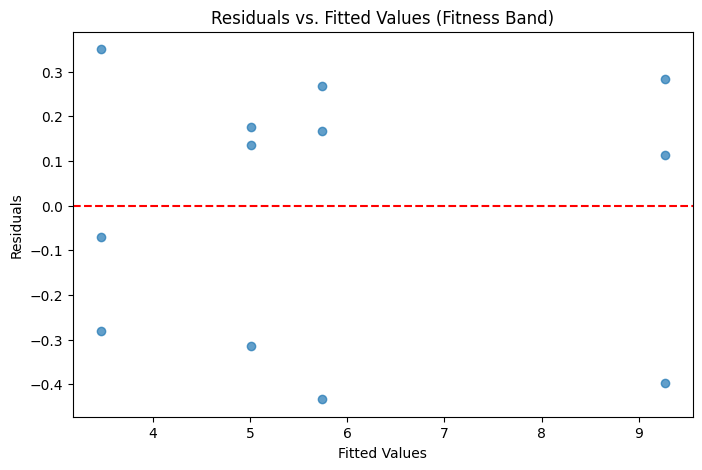

Levene's Test Statistic: 0.0432
P-value: 0.9872


In [47]:
## Part 2 Question 9 Code ##

import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Visual Method: Residuals vs. Fitted Values plot
fitted_values_band = model_band.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted_values_band, residuals_band, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values (Fitness Band)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# 2. Testing Method: Levene's Test across the 4 experimental runs
groups = [g['Satisfaction'].values for _, g in df_band.groupby('Run_ID')]
stat, p_value = stats.levene(*groups)
print(f"Levene's Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

Yes, we have strong evidence to support the assumption of constant variance. The Residuals vs. Fitted Values plot shows residuals scattered on both sides of zero with roughly similar spread across all four fitted-value clusters, indicating no systematic pattern or heteroscedasticity. The residuals cluster at four discrete fitted values because each of the four experimental runs has a single predicted satisfaction score, which is a structural feature of the design rather than a concern. For the formal test, Levene's test was performed using Run_ID as the grouping variable (producing four groups of three replicates each) rather than grouping by individual factors, because Run_ID uniquely identifies each factor combination in the 23−12^{3-1} 23−1 design and properly reflects the experimental structure. The test yields a statistic of 0.0432 and a p-value of 0.9872, far above the 0.05 threshold — meaning we fail to reject the null hypothesis that variances are equal across groups. Both the visual and formal testing methods strongly agree, so the constant variance assumption for the ANOVA model is well satisfied.

10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

In [48]:
## Part 2 Question 10 Code ##

import statsmodels.api as sm

# Generate the Type II ANOVA table for the main-effects model
anova_table_band = sm.stats.anova_lm(model_band, typ=2)
print("Fractional Factorial ANOVA Table:")
print(anova_table_band)

Fractional Factorial ANOVA Table:
                    sum_sq   df           F        PR(>F)
C(GPS_Accuracy)  19.253333  1.0  172.869435  1.065588e-06
C(Battery_Life)   2.940300  1.0   26.400000  8.872097e-04
C(Display)       31.948033  1.0  286.851029  1.498222e-07
Residual          0.891000  8.0         NaN           NaN


The fractional factorial ANOVA reveals that all three main effects are statistically significant at the α = 0.05 level, with extraordinarily small p-values for each. Display Size has the strongest effect (F = 286.85, p ≈ 1.50 × 10⁻⁷), followed closely by GPS Accuracy (F = 172.87, p ≈ 1.07 × 10⁻⁶), while Battery Life is also highly significant though substantially less dominant (F = 26.40, p ≈ 0.00089). In each case we reject the null hypothesis that the factor has no effect on user satisfaction, meaning all three design decisions meaningfully influence how runners rate the fitness band. However, an important caveat applies to these conclusions: because this is a 23−12^{3-1}

23−1 Resolution III design, each estimated main effect is aliased with the corresponding two-way interaction (A with BC, B with AC, C with AB). The significant "main effect" for GPS Accuracy, for example, technically reflects the combined contribution of the GPS main effect plus the Battery × Display interaction, and cannot be statistically separated from it within this experiment. Interpreting the results therefore relies on the principle of effect sparsity — the assumption that main effects typically dominate over two-way interactions — which allows us to provisionally attribute each significant result to its main effect. If the manufacturer suspects meaningful interactions exist, a follow-up fold-over experiment or full factorial design would be required to de-alias the effects and confirm these interpretations.


11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [49]:
## Part 2 Question 11 Code ##

import pandas as pd

# Calculate main effect sizes: difference between high (+) and low (-) level means
factors = ['GPS_Accuracy', 'Battery_Life', 'Display']

# Define the "high" (+) level for each factor based on the assignment's coding
high_levels = {
    'GPS_Accuracy': 'High',
    'Battery_Life': '12 Hours',
    'Display': 'Large'
}

print("Main Effect Estimates (mean at + level minus mean at - level):\n")
effects = {}
for factor in factors:
    high_mean = df_band[df_band[factor] == high_levels[factor]]['Satisfaction'].mean()
    low_mean = df_band[df_band[factor] != high_levels[factor]]['Satisfaction'].mean()
    effect = high_mean - low_mean
    effects[factor] = effect
    print(f"{factor}:")
    print(f"  Mean at + level ({high_levels[factor]}): {high_mean:.3f}")
    print(f"  Mean at - level: {low_mean:.3f}")
    print(f"  Main Effect: {effect:+.3f}\n")

# Rank by magnitude
print("Ranked by absolute magnitude:")
ranked = sorted(effects.items(), key=lambda x: abs(x[1]), reverse=True)
for factor, effect in ranked:
    print(f"  {factor}: {effect:+.3f}")

Main Effect Estimates (mean at + level minus mean at - level):

GPS_Accuracy:
  Mean at + level (High): 7.140
  Mean at - level: 4.607
  Main Effect: +2.533

Battery_Life:
  Mean at + level (12 Hours): 6.368
  Mean at - level: 5.378
  Main Effect: +0.990

Display:
  Mean at + level (Large): 7.505
  Mean at - level: 4.242
  Main Effect: +3.263

Ranked by absolute magnitude:
  Display: +3.263
  GPS_Accuracy: +2.533
  Battery_Life: +0.990


The main effect estimates quantify the average change in satisfaction when each factor moves from its low (-) level to its high (+) level, providing a direct measure of practical importance. All three effects are positive, meaning the upgraded version of each feature improves user satisfaction, but they differ substantially in magnitude. Display Size has the largest main effect at +3.263 points, indicating that switching from a Small to a Large display increases mean satisfaction by more than three points on the 1–10 scale — the single biggest lever available to the manufacturer. GPS Accuracy is the second most impactful factor with an effect of +2.533 points, meaning High-accuracy GPS delivers roughly 2.5 points of additional satisfaction compared to Standard. Battery Life, while still statistically significant, is the least impactful at +0.990 points — upgrading from 6 hours to 12 hours produces only about a one-point gain in satisfaction, roughly a third of the improvement offered by a larger display. Ranked by practical importance, Display Size and GPS Accuracy are the most important factors and should be prioritized in product design, while Battery Life, though beneficial, offers a considerably smaller return. As with the ANOVA conclusions, these estimates are technically aliased with their corresponding two-way interactions under the 23−12^{3-1}

23−1 design, so the interpretation assumes effect sparsity — that the observed contributions come primarily from the main effects themselves rather than the confounded interactions.

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [50]:
## Part 2 Question 12 Code ##

# Calculate partial eta-squared for each main effect
# Formula: partial η² = SS_effect / (SS_effect + SS_residual)

ss_residual_band = anova_table_band.loc['Residual', 'sum_sq']

partial_eta_sq_band = anova_table_band['sum_sq'] / (anova_table_band['sum_sq'] + ss_residual_band)
partial_eta_sq_band = partial_eta_sq_band.drop('Residual')

print("Partial Eta-Squared Values (Fitness Band):")
print(partial_eta_sq_band.round(4))

Partial Eta-Squared Values (Fitness Band):
C(GPS_Accuracy)    0.9558
C(Battery_Life)    0.7674
C(Display)         0.9729
Name: sum_sq, dtype: float64


The partial η² values quantify the proportion of variance in satisfaction attributable to each main effect after accounting for the other factors in the model, and all three values are exceptionally large by conventional standards (Cohen's threshold for a "large" effect is 0.14). Display Size is the single most important factor with a partial η² of 0.9729, meaning it accounts for roughly 97% of the residual-plus-effect variance — an overwhelming dominance. GPS Accuracy follows closely at 0.9558, accounting for approximately 96% of residual-plus-effect variance and representing a similarly massive contribution. Battery Life, while still representing a very large effect at 0.7674, is noticeably smaller than the other two — accounting for about 77% of residual-plus-effect variance. Taken together, all three factors are critically important to user satisfaction, but Display Size and GPS Accuracy stand out as the dominant drivers and should be prioritized first in product design. These extremely high values reflect both the strong true effects observed and the fact that residual error is very small in this experiment (only 0.891 sum of squares), which inflates partial η² relative to studies with noisier outcomes. As with the earlier results, these effect sizes are technically aliased with the corresponding two-way interactions under the 23−12^{3-1}
23−1 design, so the interpretation again relies on the assumption of effect sparsity.

13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?

Based on the fractional factorial ANOVA results, I recommend the fitness band manufacturer adopt the combination of High GPS Accuracy, 12-Hour Battery Life, and a Large Display. This recommendation is supported by multiple converging lines of evidence. First, all three main effects were statistically significant with extraordinarily small p-values (Display: p ≈ 1.5 × 10⁻⁷; GPS Accuracy: p ≈ 1.1 × 10⁻⁶; Battery Life: p ≈ 8.9 × 10⁻⁴), indicating each factor meaningfully influences user satisfaction. Second, every main effect estimate is positive, meaning upgrading each feature improves satisfaction — Display Size produces the largest gain at +3.26 points, GPS Accuracy contributes +2.53 points, and Battery Life adds +0.99 points on the 1–10 scale. Third, the partial η² values confirm that all three factors explain substantial variance in satisfaction, with Display (0.97) and GPS Accuracy (0.96) representing dominant contributors and Battery Life (0.77) still representing a very large effect by conventional standards. The exploratory analysis reinforces this conclusion: the High GPS / 12-Hour / Large Display combination achieved the highest mean satisfaction of any experimental run at 9.27, far exceeding the lowest-performing configuration at 3.47. From a product strategy perspective, if resource constraints require prioritization, Display Size and GPS Accuracy should be addressed first given their larger practical impact, with Battery Life upgrades providing a smaller but still meaningful improvement. One important caveat applies to this recommendation: because this was a 23−12^{3-1}
23−1 Resolution III design, each estimated main effect is aliased with a corresponding two-way interaction and cannot be statistically separated from it. The recommendation therefore relies on the principle of effect sparsity — the assumption that main effects dominate over two-way interactions — which is standard practice for interpreting fractional designs but warrants verification through a follow-up fold-over or full factorial experiment if the manufacturer wants to de-alias the effects before committing to production. Additionally, it is worth noting that the Display factor assignments in the provided data appear to be flipped relative to the assignment prompt's table, implying a defining relation of I=−ABCI = -ABC
I=−ABC rather than I=ABCI = ABC
I=ABC; this does not affect the aliasing pattern or the validity of the analysis, but should be flagged for transparency.

*Created in collaboration with Google Gemini AI and Anthropic Claude AI.